In [1]:
import pandas as pd
import numpy as np
import os
import gc
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import gc

In [2]:
INPUT_PATH = "/kaggle/input/datasets/organizations/netflix-inc/netflix-prize-data"
OUTPUT_FILE = "/kaggle/working/data.csv"

files = ["combined_data_1.txt", "combined_data_2.txt", "combined_data_3.txt",
         "combined_data_4.txt"]

print("Creating CSV at:", OUTPUT_FILE)

with open(OUTPUT_FILE, "w", buffering=1_048_576) as out_file:  # 1MB buffer
    
    for file_name in files:
        full_path = os.path.join(INPUT_PATH, file_name)
        print(f"Reading ratings from {full_path} ...")

        with open(full_path, "r") as f:
            movie_id = None

            for line in f:
                line = line.strip()

                # Movie ID lines look like: "12345:"
                if line.endswith(":"):
                    movie_id = line[:-1]

                else:
                    # line format: user_id,rating,date
                    # directly write → faster than split/join
                    out_file.write(f"{movie_id},{line}\n")

        print(f"Finished {file_name}\n")

print("CSV creation completed.")


Creating CSV at: /kaggle/working/data.csv
Reading ratings from /kaggle/input/datasets/organizations/netflix-inc/netflix-prize-data/combined_data_1.txt ...
Finished combined_data_1.txt

Reading ratings from /kaggle/input/datasets/organizations/netflix-inc/netflix-prize-data/combined_data_2.txt ...
Finished combined_data_2.txt

Reading ratings from /kaggle/input/datasets/organizations/netflix-inc/netflix-prize-data/combined_data_3.txt ...
Finished combined_data_3.txt

Reading ratings from /kaggle/input/datasets/organizations/netflix-inc/netflix-prize-data/combined_data_4.txt ...
Finished combined_data_4.txt

CSV creation completed.


In [3]:
rows = sum(1 for _ in open("data.csv")) - 1   # minus header
print("Total rows:", rows)

Total rows: 100480506


In [4]:
dtype_spec = {'movie_id': 'int32', 'user_id': 'int32', 'rating': 'int8', 'date': str}
# Read as string, then convert to datetime

# Read the CSV with specified dtypes. `low_memory=False` is no longer needed with explicit dtypes.
df = pd.read_csv('/kaggle/working/data.csv', sep=',', names=['movie_id', 'user_id', 'rating', 'date'], dtype=dtype_spec)

# Convert 'date' column to datetime objects
df['date'] = pd.to_datetime(df['date'])

# Sort the DataFrame by 'date'
df.sort_values(by='date', inplace=True)
gc.collect()

print('Done')

Done


In [5]:
print(df.head(3))
print(df.tail(3))

          movie_id  user_id  rating       date
56431994     10341   510180       4 1999-11-11
9056171       1798   510180       5 1999-11-11
58698779     10774   510180       3 1999-11-11
          movie_id  user_id  rating       date
47098649      8467  1534359       5 2005-12-31
55621336     10168  2543295       2 2005-12-31
25464092      4736  1346243       5 2005-12-31


In [6]:
df.describe()['rating']

count    1.004805e+08
mean     3.604290e+00
min      1.000000e+00
25%      3.000000e+00
50%      4.000000e+00
75%      4.000000e+00
max      5.000000e+00
std      1.085219e+00
Name: rating, dtype: float64

In [7]:
df.isnull().sum()

movie_id    0
user_id     0
rating      0
date        0
dtype: int64

In [8]:
duplicate= df.duplicated(['movie_id', 'user_id', 'rating'])
if duplicate.sum() == 0:
    print('No Duplicate values')
else:
    print(f'Total duplicate values: {duplicate.sum()}')

No Duplicate values


In [9]:
print('Stastic of Whole Data\n', "-"*40)
print(f'Total no. of Ratings: {df.shape[0]}')
print(f'Total no. of Users: {len(np.unique(df.user_id))}')
print(f'Total no. of Movies: {len(np.unique(df.movie_id))}')

Stastic of Whole Data
 ----------------------------------------
Total no. of Ratings: 100480507
Total no. of Users: 480189
Total no. of Movies: 17770


In [10]:
start = datetime.now()

# Train-Test split
df.iloc[:int(df.shape[0]*0.80)].to_csv('/kaggle/working/train.csv', index=False)
df.iloc[int(df.shape[0]*0.80):].to_csv('/kaggle/working/test.csv', index=False)

print(f'Done, total time taken: {datetime.now() - start}')

Done, total time taken: 0:03:53.035645


Spliting data into Train, Test split.

In [11]:
# Load the split data into new DataFrames
train = pd.read_csv('train.csv', parse_dates=['date'])
test = pd.read_csv('test.csv')

In [12]:
# Basic stastic of Train data
print('Basic stastic of Train Data\n','-'*40)
print(f'Total no. of Ratings: {train.shape[0]}')
print(f'Total no. of Users: {len(np.unique(train.user_id))}')
print(f'Total no. of Movies: {len(np.unique(train.movie_id))}')

Basic stastic of Train Data
 ----------------------------------------
Total no. of Ratings: 80384405
Total no. of Users: 405041
Total no. of Movies: 17424


In [13]:
# Basic stastic of Test data
print('Basic stastic of Test Data\n','-'*40)
print(f'Total no. of Ratings: {test.shape[0]}')
print(f'Total no. of Users: {len(np.unique(test.user_id))}')
print(f'Total no. of Movies: {len(np.unique(test.movie_id))}')

Basic stastic of Test Data
 ----------------------------------------
Total no. of Ratings: 20096102
Total no. of Users: 349312
Total no. of Movies: 17757


In [14]:
# EDA
def human(num, unites=['M']):
    unites = unites.lower()
    num = float(num)
    if unites == 'k':
        return str(num/10**3) + 'K'
    elif unites == 'm':
        return str(num/10**6) + 'M'
    elif unites == 'b':
        return str(num/10**9) + 'B'

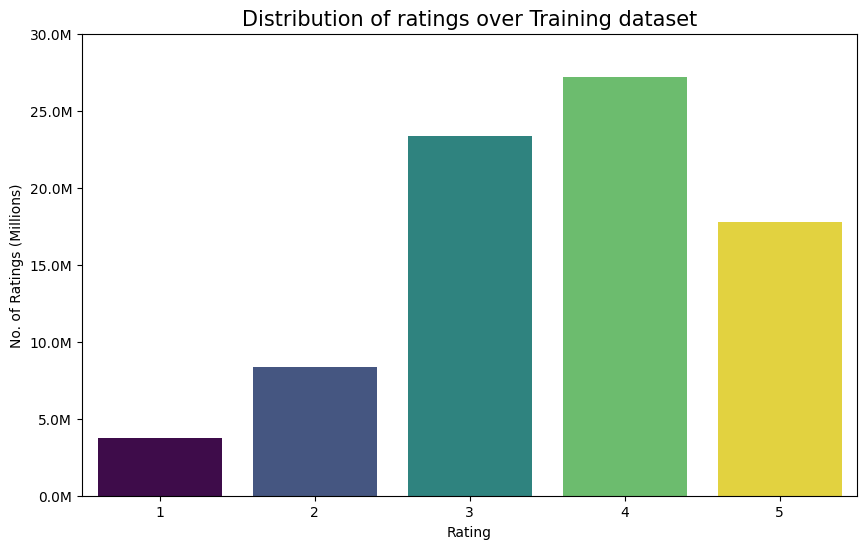

153

In [15]:
# Calculate value counts to reduce memory usage for plotting
rating_counts = train.rating.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 6))
plt.title('Distribution of ratings over Training dataset', fontsize=15)

sns.barplot(x=rating_counts.index, y=rating_counts.values, ax=ax, palette='viridis', hue=rating_counts.index, legend=False)

# Get current y-tick locations
yt_locs = ax.get_yticks()
# Set y-tick locations explicitly and then set labels
ax.set_yticks(yt_locs)
ax.set_yticklabels([human(item,'M')for item in yt_locs])

ax.set_ylabel('No. of Ratings (Millions)')
ax.set_xlabel('Rating')

plt.show()
gc.collect()

In [16]:
pd.options.mode.chained_assignment = None
train['date'] = pd.to_datetime(train['date'])
train.head()

,movie_id,user_id,rating,date
0,10341,510180,4,1999-11-11
1,1798,510180,5,1999-11-11
2,10774,510180,3,1999-11-11
3,8651,510180,2,1999-11-11
4,14660,510180,2,1999-11-11


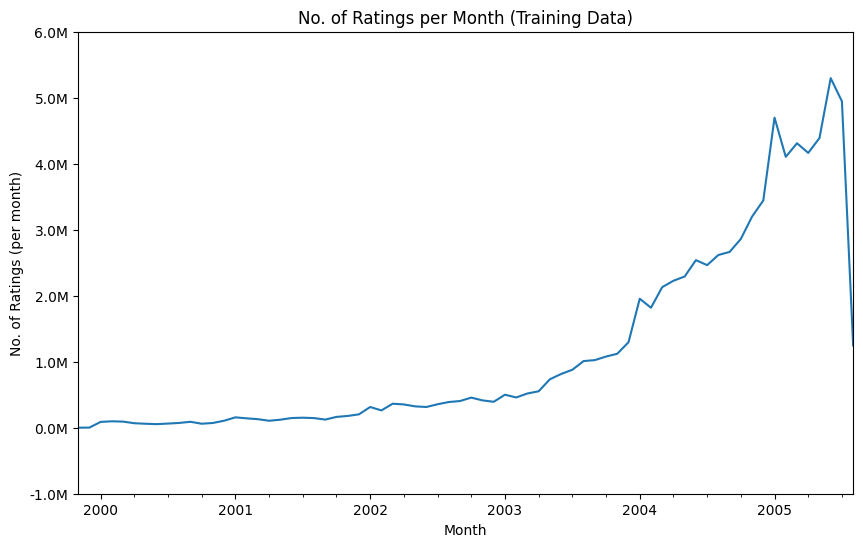

12

In [17]:
plt.figure(figsize=(10, 6))
ax = train.resample('ME', on='date')['rating'].count().plot()
ax.set_title('No. of Ratings per Month (Training Data)')
plt.xlabel('Month')
plt.ylabel('No. of Ratings (per month)')
# Get current y-tick locations
yt_locs = ax.get_yticks()
# Set y-tick locations explicitly and then set labels
ax.set_yticks(yt_locs)
ax.set_yticklabels([human(item,'M')for item in ax.get_yticks()])
plt.show()
gc.collect()

Analysis on Rating

In [18]:
movies_rated_per_user = train.groupby(by='user_id')['rating'].count().sort_values(ascending=False)
movies_rated_per_user.head()

user_id
305344     17112
2439493    15896
387418     15402
1639792     9767
1461435     9447
Name: rating, dtype: int64

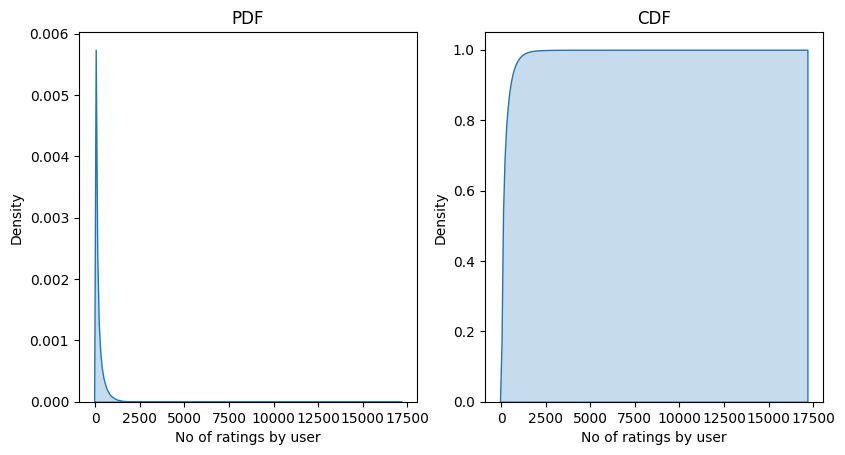

3254

In [19]:
fig = plt.figure(figsize=plt.figaspect(.5))

ax1 = plt.subplot(121)
sns.kdeplot(movies_rated_per_user, fill=True, ax=ax1)
plt.xlabel('No of ratings by user')
plt.title('PDF')

ax2 = plt.subplot(122)
sns.kdeplot(movies_rated_per_user, fill=True, cumulative=True, ax=ax2)
plt.xlabel('No of ratings by user')
plt.title('CDF')

plt.show()
gc.collect()

In [20]:
movies_rated_per_user.describe()

count    405041.000000
mean        198.459921
std         290.793238
min           1.000000
25%          34.000000
50%          89.000000
75%         245.000000
max       17112.000000
Name: rating, dtype: float64

In [21]:
quantiles = movies_rated_per_user.quantile(np.arange(0, 1.01, 0.01),
                                           interpolation='higher').astype(int)

12

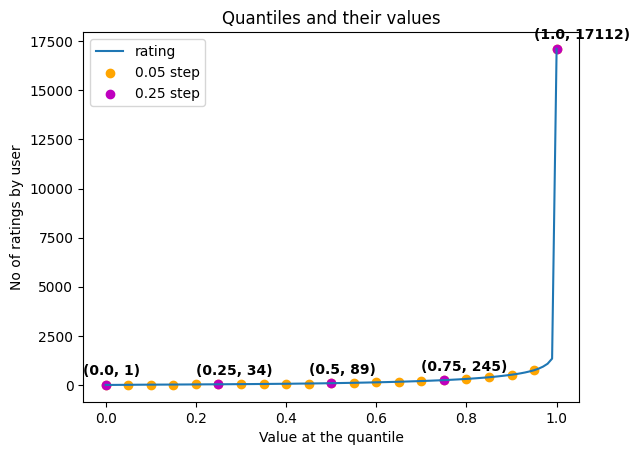

In [22]:
plt.title("Quantiles and their values")
quantiles.plot()

# quantiles with 0.05 difference
plt.scatter(x=quantiles.index[::5], y=quantiles.values[::5], c='orange', label='0.05 step')

# quantiles with 0.25 difference
plt.scatter(x=quantiles.index[::25], y=quantiles.values[::25], c='m', label='0.25 step')

plt.ylabel('No of ratings by user')
plt.xlabel('Value at the quantile')
plt.legend(loc='best')

# annotate the 25th, 50th, 75th and 100th percentile values....
for x, y in zip(quantiles.index[::25], quantiles[::25]):
    plt.annotate(text="({}, {})".format(x, y),xy=(x, y), xytext=(x - 0.05, y + 500),
                 fontweight='bold')
gc.collect()

In [23]:
quantiles[::5]

0.00        1
0.05        7
0.10       15
0.15       21
0.20       27
0.25       34
0.30       41
0.35       50
0.40       60
0.45       73
0.50       89
0.55      109
0.60      133
0.65      163
0.70      199
0.75      245
0.80      307
0.85      392
0.90      520
0.95      749
1.00    17112
Name: rating, dtype: int64

In [24]:
print('No of ratings at last 5 percentile : {}'.format(sum(
    movies_rated_per_user >= quantiles.iloc[95])))

No of ratings at last 5 percentile : 20305


In [25]:
gc.collect()

4014

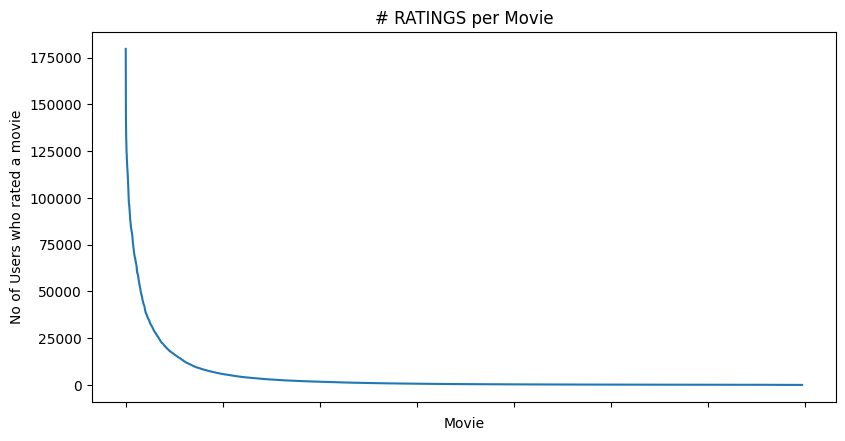

In [26]:
movies_rated_per_user = train.groupby(by='movie_id')['rating'].count().sort_values(ascending=False)

fig = plt.figure(figsize=plt.figaspect(.5))
ax = plt.gca()

plt.plot(movies_rated_per_user.values)
plt.title('# RATINGS per Movie')
plt.xlabel('Movie')
plt.ylabel('No of Users who rated a movie')

ax.set_xticklabels([])

plt.show()

In [27]:
gc.collect()

4537

In [28]:
pd.options.mode.chained_assignment = None
train['day_of_week'] = train.date.dt.day_name()
train.head()

,movie_id,user_id,rating,date,day_of_week
0,10341,510180,4,1999-11-11,Thursday
1,1798,510180,5,1999-11-11,Thursday
2,10774,510180,3,1999-11-11,Thursday
3,8651,510180,2,1999-11-11,Thursday
4,14660,510180,2,1999-11-11,Thursday


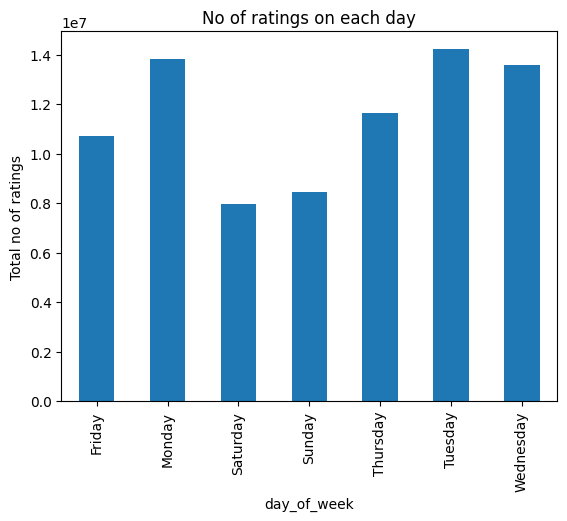

In [29]:
counts = train['day_of_week'].value_counts().sort_index()
counts.plot(kind='bar')
plt.title('No of ratings on each day')
plt.ylabel('Total no of ratings')
plt.show()

In [30]:
gc.collect()

3602

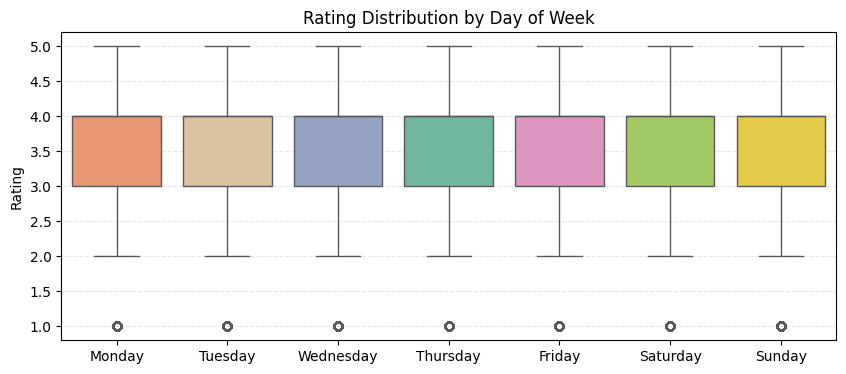

In [31]:
# Ensure proper weekday order
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday',
             'Saturday','Sunday']

plt.figure(figsize=(10,4))


sns.boxplot(x='day_of_week', y='rating', hue='day_of_week', data=train,
            order=day_order, palette='Set2', legend=False)

plt.title('Rating Distribution by Day of Week')
plt.xlabel('')
plt.ylabel('Rating')
plt.grid(axis='y', linestyle='--', alpha=0.3)

In [32]:
gc.collect()

6401

In [33]:
avg_week_df = train.groupby(by=['day_of_week'])['rating'].mean()
print(f'Average ratings:\n{avg_week_df}')

Average ratings:
day_of_week
Friday       3.585274
Monday       3.577250
Saturday     3.591791
Sunday       3.594144
Thursday     3.582463
Tuesday      3.574438
Wednesday    3.583751
Name: rating, dtype: float64


Creating Sparse matrix from train data

In [34]:
from scipy import sparse

if os.path.isfile('train_sparse_matrix.npz'):
  print('it is present in your pwd, getting it from disk....')
  train_sparse_matrix = sparse.load_npz('train_sparse_matrix.npz')
  print('Done')
else:
  print('We are creating sparse_matrix from dataframe')
  max_user_id = train['user_id'].max()
  max_movie_id = train['movie_id'].max()
  train_sparse_matrix = sparse.csr_matrix((train.rating.values, (train.user_id.values, train.movie_id.values)),
                                         shape=(max_user_id + 1, max_movie_id + 1))

print('Done.It\'s shape is :(user, movie): ', train_sparse_matrix.shape)
print('Saving it into disk for further usage..')
sparse.save_npz("train_sparse_matrix.npz", train_sparse_matrix)
print('Done..\n')

We are creating sparse_matrix from dataframe
Done.It's shape is :(user, movie):  (2649430, 17771)
Saving it into disk for further usage..
Done..



In [35]:
us,mv = train_sparse_matrix.shape
elem = train_sparse_matrix.count_nonzero()
print(f'sparsity of train matrix:{(1-(elem/(us*mv)))*100}%')

sparsity of train matrix:99.8292709259195%


Sparse matrix from train data

In [36]:
if os.path.isfile('test_sparse_matrix.npz'):
  print('it is present in your pwd, getting it from disk....')
  train_sparse_matrix = sparse.load_npz('test_sparse_matrix.npz')
  print('Done')
else:
  print('We are creating sparse_matrix from dataframe')
  test_sparse_matrix = sparse.csr_matrix((test.rating.values, (test.user_id.values, test.movie_id.values)),
                                         shape=(max_user_id + 1, max_movie_id + 1))

print('Done.It\'s shape is :(user, movie): ', test_sparse_matrix.shape)
print('Saving it into disk for further usage..')
sparse.save_npz("train_sparse_matrix.npz", test_sparse_matrix)
print('Done..\n')

We are creating sparse_matrix from dataframe
Done.It's shape is :(user, movie):  (2649430, 17771)
Saving it into disk for further usage..
Done..



In [37]:
us,mv = test_sparse_matrix.shape
elem = test_sparse_matrix.count_nonzero()
print(f'sparsity of test matrix:{(1-(elem/(us*mv)))*100}%')

sparsity of test matrix:99.95731772988694%


In [38]:
def avg_ratings(sparse_matrix, of_users):
    ax = 1 if of_users else 0

    # .Al convert column matrix to 1-D array
    ratings_sum = sparse_matrix.sum(axis=ax).A1
    # bollen matrix for ratings
    is_rated = sparse_matrix!= 0
    # no of ratings that each user OR movie
    no_of_ratings = is_rated.sum(axis=ax).A1
    # max user and max movie ids in matrix
    u,m = sparse_matrix.shape
    # creating a dict of users and their avg ratings
    avg_ratings = {i : ratings_sum[i]/no_of_ratings[i]
                          for i in range(u if of_users else m)
                             if no_of_ratings[i]!= 0}
    return avg_ratings

In [39]:
train_avg = dict()
train_global_avg = train_sparse_matrix.sum()/train_sparse_matrix.count_nonzero()
train_avg['global'] = train_global_avg
train_avg

{'global': np.float64(3.582890686321557)}

In [40]:
train_avg['user_id'] = avg_ratings(train_sparse_matrix, of_users = True)
print(f'Average rating of user 10 : {train_avg['user_id'][10]}')

Average rating of user 10 : 3.3781094527363185


In [41]:
train_avg['movie_id'] = avg_ratings(train_sparse_matrix, of_users=False)
print(f'Average rating of movie 15 : {train_avg['movie_id'][15]}')

Average rating of movie 15 : 3.3038461538461537


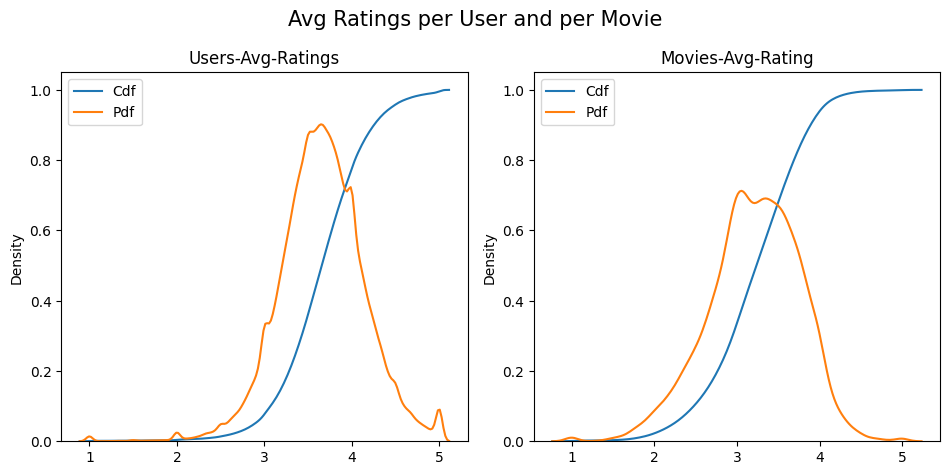

In [42]:
# draw PDFs for average rating per user and per movie
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=plt.figaspect(.5))
fig.suptitle('Avg Ratings per User and per Movie', fontsize=15)

# ---------- USERS ----------
ax1.set_title('Users-Avg-Ratings')
user_averages = list(train_avg['user_id'].values())
# CDF
sns.kdeplot(user_averages, ax=ax1, cumulative=True, label='Cdf')
# PDF
sns.kdeplot(user_averages, ax=ax1, label='Pdf')
ax1.legend()

# ---------- MOVIES ----------
ax2.set_title('Movies-Avg-Rating')
movie_averages = list(train_avg['movie_id'].values())
# CDF
sns.kdeplot(movie_averages, ax=ax2, cumulative=True, label='Cdf')
# PDF
sns.kdeplot(movie_averages, ax=ax2, label='Pdf')
ax2.legend()
plt.tight_layout()

plt.show()

In [43]:
gc.collect()

6290

In [44]:
# Counting unique users in the original dataframe
total_users = len(np.unique(df.user_id))

# Counting users we have average ratings for from the training set
users_train = len(train_avg['user_id'])

# Calculating the difference to find "new" users
new_users = total_users - users_train

print('\nTotal number of Users      :', total_users)
print('\nNumber of Users in Train data :', users_train)
print("\nNo of Users that didn't appear in train data: {}({} %) \n ".format(
    new_users, np.round((new_users/total_users)*100, 2)))


Total number of Users      : 480189

Number of Users in Train data : 405041

No of Users that didn't appear in train data: 75148(15.65 %) 
 


In [45]:
total_movies = len(np.unique(df.movie_id))
movies_train = len(train_avg['movie_id'])
new_movies = total_movies - movies_train

print('\nTotal number of Movies      :', total_movies)
print('\nNumber of Movies in Train data :', movies_train)
print("\nNo of Movies that didn't appear in train data: {}({} %) \n ".format(
    new_movies, np.round((new_movies/total_movies)*100, 2)))


Total number of Movies      : 17770

Number of Movies in Train data : 17424

No of Movies that didn't appear in train data: 346(1.95 %) 
 


In [46]:
from sklearn.metrics.pairwise import cosine_similarity
start = datetime.now()
if not os.path.isfile('m_m_sim_sparse.npz'):
    print("It seems you don't have that file. Computing movie_movie similarity...")
    start = datetime.now()
    m_m_sim_sparse = cosine_similarity(X=train_sparse_matrix.T, dense_output=False)
    print("Done..")
    # store this sparse matrix in disk before using it. For future purposes
    print("Saving it to disk without the need of re-computing it again.. ")
    sparse.save_npz("m_m_sim_sparse.npz", m_m_sim_sparse)
    print("Done..")
else:
    print("It is there, We will get it.")
    m_m_sim_sparse = sparse.load_npz("m_m_sim_sparse.npz")
    print("Done ...")

print("It's a ", m_m_sim_sparse.shape, " dimensional matrix")

print(datetime.now() - start)

It seems you don't have that file. Computing movie_movie similarity...
Done..
Saving it to disk without the need of re-computing it again.. 
Done..
It's a  (17771, 17771)  dimensional matrix
0:09:07.487845


In [47]:
 m_m_sim_sparse.shape

(17771, 17771)

In [48]:
# First Let's load the movie details into some dataframe..
# movie details are in 'netflix/movie_titles.csv'

movie_titles = pd.read_csv("/kaggle/input/datasets/organizations/netflix-inc/netflix-prize-data/movie_titles.csv",
                     header=None,names=["movie_id","year_of_release","titles"],index_col="movie_id",
                     encoding="ISO-8859-1", engine="python", on_bad_lines="skip")
movie_titles.head()

,year_of_release,titles
movie_id,,
1,2003.0,Dinosaur Planet
2,2004.0,Isle of Man TT 2004 Review
3,1997.0,Character
4,1994.0,Paula Abdul's Get Up & Dance
5,2004.0,The Rise and Fall of ECW


In [49]:
mv_id = 67

print("\nMovie ----->", movie_titles.loc[mv_id].values[1])

print("\nIt has {} Ratings from users.".format(train_sparse_matrix[:,mv_id].count_nonzero()))

print("\nWe have {} movies which are similar to this and we will get only the top 10")


Movie -----> Vampire Journals

It has 270 Ratings from users.

We have {} movies which are similar to this and we will get only the top 10


In [50]:
similarities = m_m_sim_sparse[mv_id].toarray().ravel()

similar_indices = similarities.argsort()[::-1][1:]

similarities[similar_indices]

sim_indices = similarities.argsort()[::-1][1:] # It will sort and reverse the array
                                               # and return its indices (movie_ids)

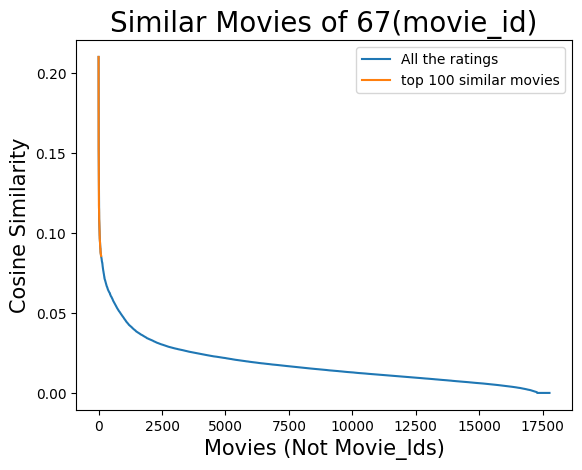

In [51]:
plt.plot(similarities[sim_indices], label='All the ratings')
plt.plot(similarities[sim_indices[:100]], label='top 100 similar movies')
plt.title("Similar Movies of {}(movie_id)".format(mv_id), fontsize=20)
plt.xlabel("Movies (Not Movie_Ids)", fontsize=15)
plt.ylabel("Cosine Similarity", fontsize=15)
plt.legend()
plt.show()

In [52]:
movie_titles.loc[sim_indices[:10]]

,year_of_release,titles
movie_id,,
323,1999.0,Modern Vampires
4044,1998.0,Subspecies 4: Bloodstorm
1688,1993.0,To Sleep With a Vampire
13962,2001.0,Dracula: The Dark Prince
12053,1993.0,Dracula Rising
16279,2002.0,Vampires: Los Muertos
4667,1996.0,Vampirella
1900,1997.0,Club Vampire
13873,2001.0,The Breed
